# 20. vMF pooled factor-PVAR results

This notebook analyzes outputs from the pooled vMF factor‑PVAR model.

Goals:
1. Load saved outputs.
2. Evaluate predictive performance.
3. Inspect latent factor structure.
4. Explore relationships with attention and p_factor.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import config

## Paths and file checks

In [11]:
OUT = PROJECT_ROOT / config.OUTPUT_DIR


metrics_path = OUT / "vmf_pvar_pooled_metrics.csv"
artifacts_path = OUT / "vmf_pvar_pooled_artifacts.npz"
targets_path = OUT / "vmf_pvar_pooled_targets.csv"
latent_summary_path = OUT / "vmf_pvar_pooled_latent_subject_summary.csv"
unit_meta_path = OUT / "vmf_pvar_pooled_unit_meta.csv"
feature_info_path = OUT / "vmf_pvar_pooled_feature_info.csv"

print("OUTPUT_DIR:", OUT)
print("metrics exists:", metrics_path.exists())
print("artifacts exists:", artifacts_path.exists())
print("targets exists:", targets_path.exists())
print("latent summary exists:", latent_summary_path.exists())
print("unit meta exists:", unit_meta_path.exists())
print("feature info exists:", feature_info_path.exists())

OUTPUT_DIR: D:\Programming\EEG-Research\outputs
metrics exists: True
artifacts exists: True
targets exists: True
latent summary exists: True
unit meta exists: True
feature info exists: True


## Optional rerun switch

In [12]:
RUN_MODEL = False

if RUN_MODEL:
    from scripts.run_vmf_factor_pvar_pooled_runner import run_vmf_pvar_pooled
    run_vmf_pvar_pooled()

## Load outputs

In [13]:
metrics = pd.read_csv(metrics_path)
targets = pd.read_csv(targets_path)
unit_meta = pd.read_csv(unit_meta_path)
feature_info = pd.read_csv(feature_info_path)

latent_summary = None
if latent_summary_path.exists():
    latent_summary = pd.read_csv(latent_summary_path)

art = np.load(artifacts_path, allow_pickle=True)

y_true_oof = art["y_true_oof"]
y_pred_oof = art["y_pred_oof"]
f_t = art["f_t"]
g_t = art["g_t"]
h_t = art["h_t"]
Lambda = art["Lambda"]
loss_history = art["loss_history"]
units = art["units"]
tasks = art["tasks"]
feature_names = art["feature_names"]
x_mean = art["x_mean"]
x_std = art["x_std"]
train_end = int(art["train_end"][0])

print("y_true_oof shape:", y_true_oof.shape)
print("y_pred_oof shape:", y_pred_oof.shape)
print("f_t shape:", f_t.shape)
print("g_t shape:", g_t.shape)
print("h_t shape:", h_t.shape)
print("Lambda shape:", Lambda.shape)
print("train_end:", train_end)

y_true_oof shape: (531822, 7)
y_pred_oof shape: (531822, 7)
f_t shape: (4108, 3)
g_t shape: (4108, 3)
h_t shape: (4108, 3)
Lambda shape: (302, 7, 3)
train_end: 4109


## Metrics

In [14]:
metrics

,mode,N_units,common_T,K,p,rf,rg,rh,max_iter,tol,train_frac,train_end,mse,rmse,r2,accuracy,kl,cross_entropy,baseline_task,task_levels
0,vmf_pooled_factor_pvar,302,5870,7,65,3,3,3,15,0.0001,0.7,4109,0.088761,0.297927,0.169816,0.439895,1.620278,1.757424,DespicableMe,DespicableMe|DiaryOfAWimpyKid|FunwithFractals|...


## Recompute performance metrics

In [15]:
EPS = 1e-12

mse = float(np.mean((y_true_oof - y_pred_oof)**2))
rmse = float(np.sqrt(mse))

true_state = np.argmax(y_true_oof, axis=-1)
pred_state = np.argmax(y_pred_oof, axis=-1)
acc = float(np.mean(true_state == pred_state))

p = np.clip(y_true_oof, EPS, 1.0)
q = np.clip(y_pred_oof, EPS, 1.0)
p = p / np.sum(p, axis=-1, keepdims=True)
q = q / np.sum(q, axis=-1, keepdims=True)

kl = float(np.mean(np.sum(p*(np.log(p)-np.log(q)), axis=-1)))
cross_entropy = float(-np.mean(np.sum(p*np.log(q), axis=-1)))

pd.DataFrame([{
    "mse": mse,
    "rmse": rmse,
    "accuracy": acc,
    "kl": kl,
    "cross_entropy": cross_entropy
}])

,mse,rmse,accuracy,kl,cross_entropy
0,0.088761,0.297927,0.439895,1.620278,1.757424


## ALS training loss

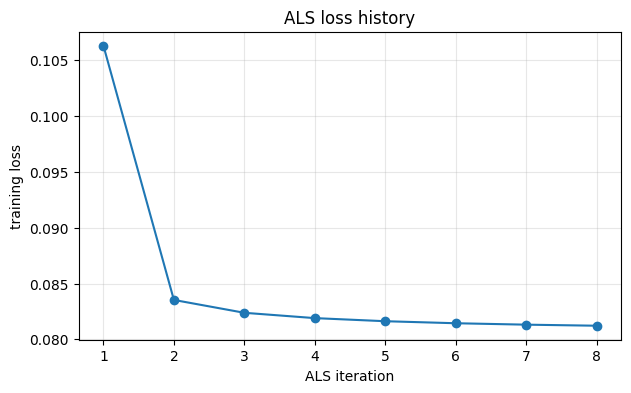

In [16]:
plt.figure(figsize=(7,4))
plt.plot(np.arange(1,len(loss_history)+1), loss_history, marker="o")
plt.xlabel("ALS iteration")
plt.ylabel("training loss")
plt.title("ALS loss history")
plt.grid(alpha=0.3)
plt.show()

## State diagnostics

In [17]:
K = y_true_oof.shape[1]

per_state_mse = np.mean((y_true_oof - y_pred_oof)**2, axis=0)
per_state_mae = np.mean(np.abs(y_true_oof - y_pred_oof), axis=0)

per_state_corr = []
for k in range(K):
    a = y_true_oof[:,k]
    b = y_pred_oof[:,k]
    if np.std(a) < 1e-12 or np.std(b) < 1e-12:
        per_state_corr.append(np.nan)
    else:
        per_state_corr.append(np.corrcoef(a,b)[0,1])

pd.DataFrame({
    "state": np.arange(K),
    "mse": per_state_mse,
    "mae": per_state_mae,
    "corr": per_state_corr
})

,state,mse,mae,corr
0,0,0.147092,0.303118,0.411852
1,1,0.099393,0.208625,0.329111
2,2,0.116489,0.245826,0.441904
3,3,0.087756,0.189403,0.459486
4,4,0.048045,0.103002,0.387604
5,5,0.072254,0.156656,0.456809
6,6,0.050297,0.105719,0.331964


## Example probability paths

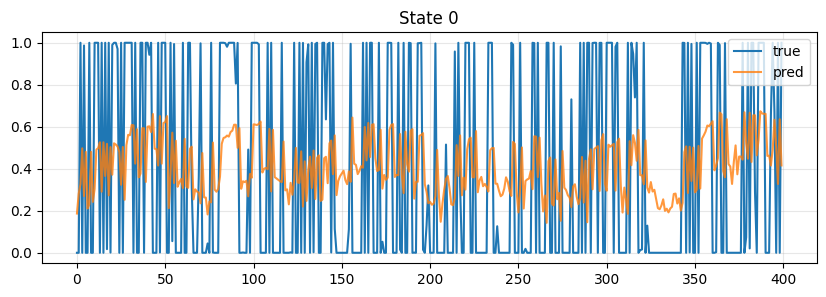

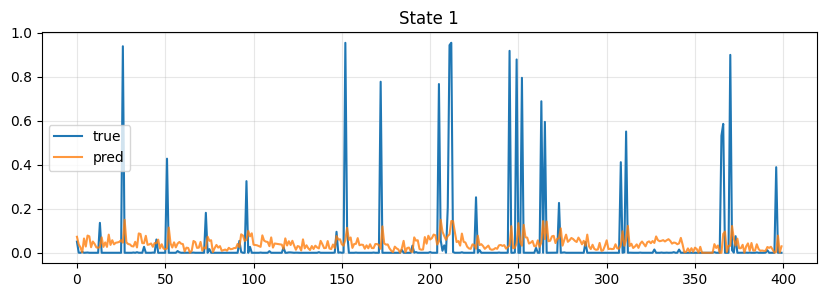

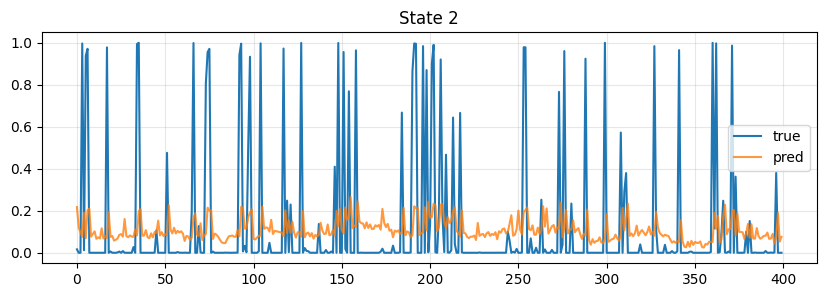

In [18]:
def plot_state_paths(states=(0,1,2), n=400):
    for k in states:
        plt.figure(figsize=(10,3))
        plt.plot(y_true_oof[:n,k], label="true")
        plt.plot(y_pred_oof[:n,k], label="pred", alpha=0.8)
        plt.title(f"State {k}")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

plot_state_paths()

## Confusion matrix

In [19]:
conf = pd.crosstab(
    pd.Series(true_state,name="true"),
    pd.Series(pred_state,name="pred")
)
conf

pred,0,1,2,3,4,5,6
true,,,,,,,
0,89067,10297,21494,8908,1130,5298,1366
1,22832,25715,18260,5201,1137,2938,1345
2,28731,11460,55517,6686,301,4052,215
3,23325,5879,11614,30969,1185,4795,769
4,12605,4794,4309,4715,6853,2297,319
5,18129,4983,9754,5877,877,20557,402
6,14592,6273,3900,2597,451,1784,5268


## Latent structure

In [20]:
print("f_t:", f_t.shape)
print("g_t:", g_t.shape)
print("h_t:", h_t.shape)
print("Lambda:", Lambda.shape)

f_t: (4108, 3)
g_t: (4108, 3)
h_t: (4108, 3)
Lambda: (302, 7, 3)


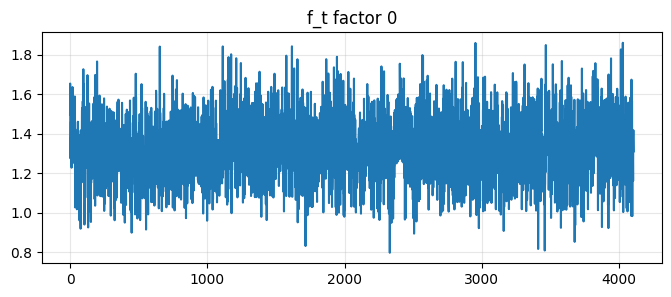

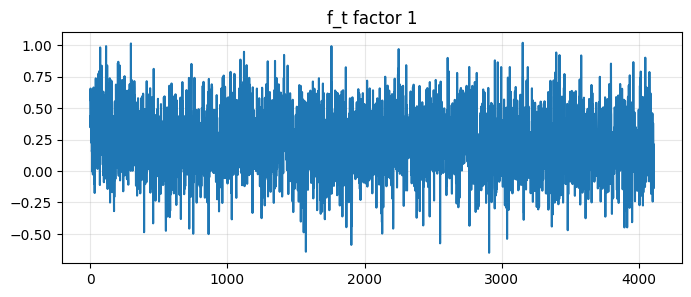

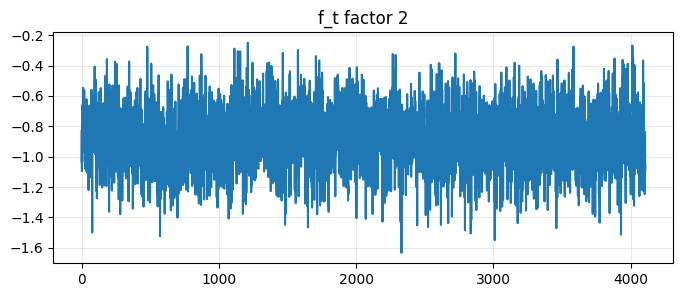

In [21]:
for j in range(f_t.shape[1]):
    plt.figure(figsize=(8,3))
    plt.plot(f_t[:,j])
    plt.title(f"f_t factor {j}")
    plt.grid(alpha=0.3)
    plt.show()

## Lambda loading summaries

In [22]:
lambda_fro = np.linalg.norm(Lambda, axis=(1,2))
lambda_abs_mean = np.mean(np.abs(Lambda), axis=(1,2))

pd.DataFrame({
    "unit_id": units,
    "task": tasks,
    "lambda_fro": lambda_fro,
    "lambda_abs_mean": lambda_abs_mean
}).head()

,unit_id,task,lambda_fro,lambda_abs_mean
0,NDARAA306NT2|ThePresent,ThePresent,0.261198,0.034839
1,NDARAA306NT2|FunwithFractals,FunwithFractals,0.541865,0.064550
2,NDARAA306NT2|DiaryOfAWimpyKid,DiaryOfAWimpyKid,0.314398,0.046176
3,NDARAA306NT2|DespicableMe,DespicableMe,0.216808,0.034955
4,NDARAA504CRN|ThePresent,ThePresent,0.293032,0.041721


## Latent summary and outcomes

In [23]:
if latent_summary is not None:
    latent_summary.head()
else:
    print("latent summary file missing")

## Correlation with outcomes

In [24]:
if latent_summary is not None:

    cols = [
        "lambda_fro",
        "lambda_abs_mean",
        "latent_bar_norm",
        "latent_bar_mean",
        "latent_bar_std"
    ] + [c for c in latent_summary.columns if c.startswith("lambda_colnorm_")]

    outcomes = [c for c in ["attention","p_factor"] if c in latent_summary.columns]

    rows = []
    for outcome in outcomes:
        for c in cols:
            tmp = latent_summary[[c,outcome]].dropna()
            if len(tmp) < 5:
                corr = np.nan
            else:
                corr = np.corrcoef(tmp[c], tmp[outcome])[0,1]

            rows.append({
                "outcome": outcome,
                "latent_feature": c,
                "corr": corr,
                "n": len(tmp)
            })

    pd.DataFrame(rows).sort_values(["outcome","corr"], ascending=[True,False])

else:
    print("latent summary missing")

## Feature information

In [25]:
feature_info.head(20)

,feature_name,mean_train,std_train
0,entropy,0.137364,0.247305
1,occupancy_roll_state_0,0.255849,0.189296
2,occupancy_roll_state_1,0.144024,0.130506
3,occupancy_roll_state_2,0.201029,0.180951
4,occupancy_roll_state_3,0.152630,0.177868
5,occupancy_roll_state_4,0.067089,0.114159
6,occupancy_roll_state_5,0.115549,0.149954
7,occupancy_roll_state_6,0.063830,0.093255
8,switching_rate_roll,0.573385,0.200667
9,volatility_roll,1.140739,0.390841
